In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_recall_curve, roc_curve, auc, precision_score, recall_score, f1_score,roc_auc_score
from keras.layers import Input, Dense
from keras.models import Model, load_model, Sequential
from keras import losses
from tensorflow.keras.callbacks import Callback
import tensorflow as tf
#Our Models 

from models.rand_autoencoder import RandAE
from preprocessing.scalers import own_scaler, mm_scaler, qs_mm_scaler
from models.isolation_forest_model import IsolationForestModel
from models.one_class_svm_model import OneClassSVMModel

In [3]:
# Cell 2: Load and Inspect Data
df1= pd.read_csv(r"mnist_0and6.csv")
print("Dataset Shape:", df1.shape)
print("Class Distribution:\n", df1['Class'].value_counts())

Dataset Shape: (7603, 785)
Class Distribution:
 Class
0    6903
6     700
Name: count, dtype: int64


In [4]:
# Extract features and labels
X = df1.drop("Class", axis=1).values
y = df1["Class"].values

In [5]:
# Normalize pixel values to [0, 1]
X = X / 255.0

# Map labels: 0 (normal) -> 0, 6 (anomaly) -> 1
y_binary = np.where(y == 6, 1, 0)

In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, stratify=y_binary, random_state=1)
print("Train Shape:", X_train.shape, "Test Shape:", X_test.shape)

Train Shape: (6082, 784) Test Shape: (1521, 784)


In [7]:
# Filter normal data (digit 0) for training
normal_mask = y_train == 0
X_train_normal = X_train[normal_mask]
print("Normal Training Samples (Digit 0):", X_train_normal.shape[0])

Normal Training Samples (Digit 0): 5522


In [8]:
Rand_Ae= RandAE(input_dim=784, hidden_dims=[512, 256, 128, 256, 512], drop_ratio=0.35)
Rand_Ae.compile(optimizer="adam", loss="mse", run_eagerly=True)

In [9]:
history = Rand_Ae.fit(
    X_train_normal, X_train_normal,
    epochs=50,  # Increased max epochs, early stopping will halt if no improvement
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 208ms/step - loss: 0.1560 - val_loss: 0.0691
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - loss: 0.0687 - val_loss: 0.0643
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 0.0637 - val_loss: 0.0552
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - loss: 0.0537 - val_loss: 0.0475
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - loss: 0.0454 - val_loss: 0.0392
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 0.0389 - val_loss: 0.0353
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - loss: 0.0342 - val_loss: 0.0302
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - loss: 0.0301 - val_loss: 0.0283
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - loss: 0.0285 - val_loss: 0.0274
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 0.0278 - val_loss: 0.0265
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 0.0265 - val_loss: 0.0246
Epoch 12/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step

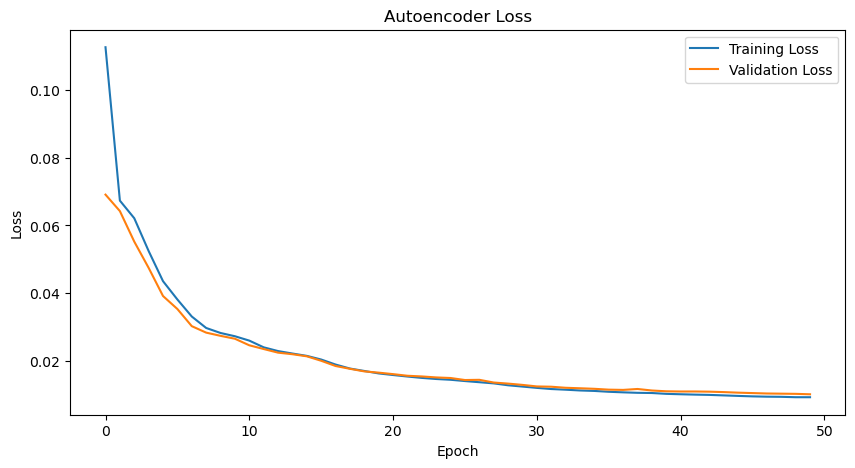

In [10]:
# Cell 7: Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
def build_autoencoder(input_dim=784):
    input_layer = Input(shape=(input_dim,))
    
    # Encoder
    encoded = Dense(512, activation='relu')(input_layer)
    encoded = Dense(256, activation='relu')(encoded)
    encoded = Dense(128, activation='relu')(encoded)  # bottleneck
    
    # Decoder
    decoded = Dense(256, activation='relu')(encoded)
    decoded = Dense(512, activation='relu')(decoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)
    
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'], run_eagerly=True)
    return autoencoder

In [12]:
normal_ae = build_autoencoder(input_dim=784)
normal_ae.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 784)                 │         402,192 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,132,944 (4.32 MB)

 Trainable params: 1,132,944 (4.32 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history1 = normal_ae.fit(X_train, X_train,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(X_test, X_test))

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 9.7715e-04 - loss: 0.4877 - val_accuracy: 0.0026 - val_loss: 0.2624
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.0040 - loss: 0.2495 - val_accuracy: 0.0046 - val_loss: 0.2097
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.0032 - loss: 0.2012 - val_accuracy: 0.0053 - val_loss: 0.1820
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.0054 - loss: 0.1751 - val_accuracy: 0.0033 - val_loss: 0.1630
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.0044 - loss: 0.1581 - val_accuracy: 0.0033 - val_loss: 0.1511
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.0051 - loss: 0.1460 - val_accuracy: 0.0039 - val_loss: 0.1386
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.0056 - loss: 0.1359 - val_accuracy: 0.0059 - val_loss: 0.1309
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.0070 - loss: 0.1283 - val_accuracy

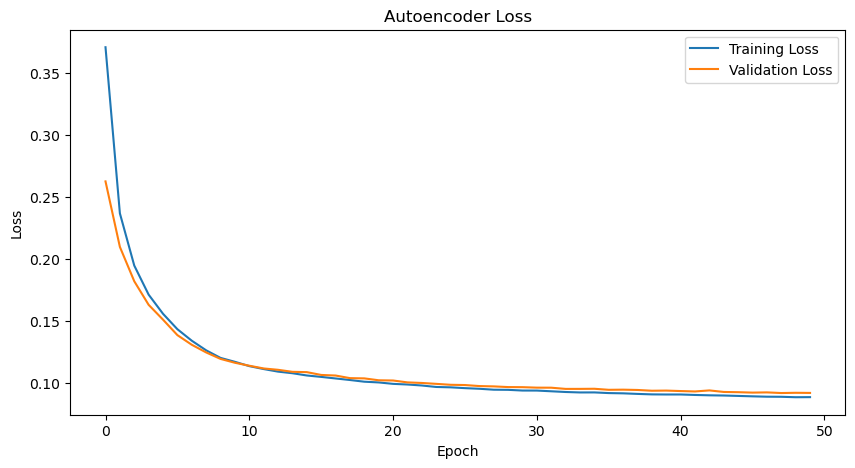

In [14]:
# Cell 7: Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [15]:
# Adjust contamination/nu based on your fraud rate
iso_model = IsolationForestModel(contamination=0.05, random_state=1)
iso_model.fit(X_train)

In [16]:
iso_pred = iso_model.predict(X_test)

In [17]:
iso_pred = np.where(iso_pred == 6, 1, 0)

In [18]:
svm_model = OneClassSVMModel(nu=0.01)
svm_model.fit(X_train)

In [19]:
svm_pred = svm_model.predict(X_test)

In [20]:
svm_pred = np.where(svm_pred == 6, 1, 0)

In [21]:
input_data = X_test
input_labels = y_test

In [22]:
results = []

def evaluate_model(name, model, input_data, input_labels, is_autoencoder=True):
    print(f"\n=== Results for {name} ===")

    if is_autoencoder:
        pred = model.predict(input_data)
        reconstruction_loss = np.square(pred - input_data).mean(axis=1)

        # === Custom threshold search for best F1 ===
        thresholds = np.linspace(reconstruction_loss.min(), reconstruction_loss.max(), 10)

        best_threshold = None
        best_f1 = 0
        best_metrics = {}
        best_pred = None

        for t in thresholds:
            outlier_pred = np.where(reconstruction_loss > t, 1, 0)
            f1 = f1_score(input_labels, outlier_pred)

            if f1 > best_f1:
                best_f1 = f1
                best_threshold = t
                best_pred = outlier_pred
                best_metrics = {
                    'f1_score': f1,
                    'precision': precision_score(input_labels, outlier_pred),
                    'recall': recall_score(input_labels, outlier_pred),
                    'accuracy': accuracy_score(input_labels, outlier_pred),
                    'confusion_matrix': confusion_matrix(input_labels, outlier_pred)
                }

        outlier_pred = best_pred
        outlier_scores = reconstruction_loss  # still used for ROC/PRC
        print(f"Selected threshold = {best_threshold:.6f} with F1 = {best_f1:.4f}")

    else:
        raw_pred = model.predict(input_data)
        outlier_pred = np.where(raw_pred == -1, 1, 0)
        if hasattr(model, "decision_function"):
            outlier_scores = -model.decision_function(input_data)
        else:
            outlier_scores = outlier_pred

    # Store for plotting
    results.append({
        "name": name,
        "y_true": input_labels,
        "y_pred": outlier_pred,
        "scores": outlier_scores
    })

    # Print report
    cr = classification_report(input_labels, outlier_pred)
    print(cr)



In [23]:
# Your corrected model names
evaluate_model("RandAE", Rand_Ae, input_data, input_labels, is_autoencoder=True)
evaluate_model("NormalAE", normal_ae, input_data, input_labels, is_autoencoder=True)
evaluate_model("Isolation Forest", iso_model, input_data, input_labels, is_autoencoder=False)
evaluate_model("One-Class SVM", svm_model, input_data, input_labels, is_autoencoder=False)


=== Results for RandAE ===
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Selected threshold = 0.027673 with F1 = 0.8478
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.86      0.84      0.85       140

    accuracy                           0.97      1521
   macro avg       0.92      0.91      0.92      1521
weighted avg       0.97      0.97      0.97      1521


=== Results for NormalAE ===
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Selected threshold = 0.008411 with F1 = 0.3036
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      1381
           1       0.23      0.45      0.30       140

    accuracy                           0.81      1521
   macro avg       0.58      0.65      0.60      1521
weighted avg       0.87      0.81      0.84      1521


=== Results for Isolation Forest ===
              precision    recall  f1-score   support

           0       0.

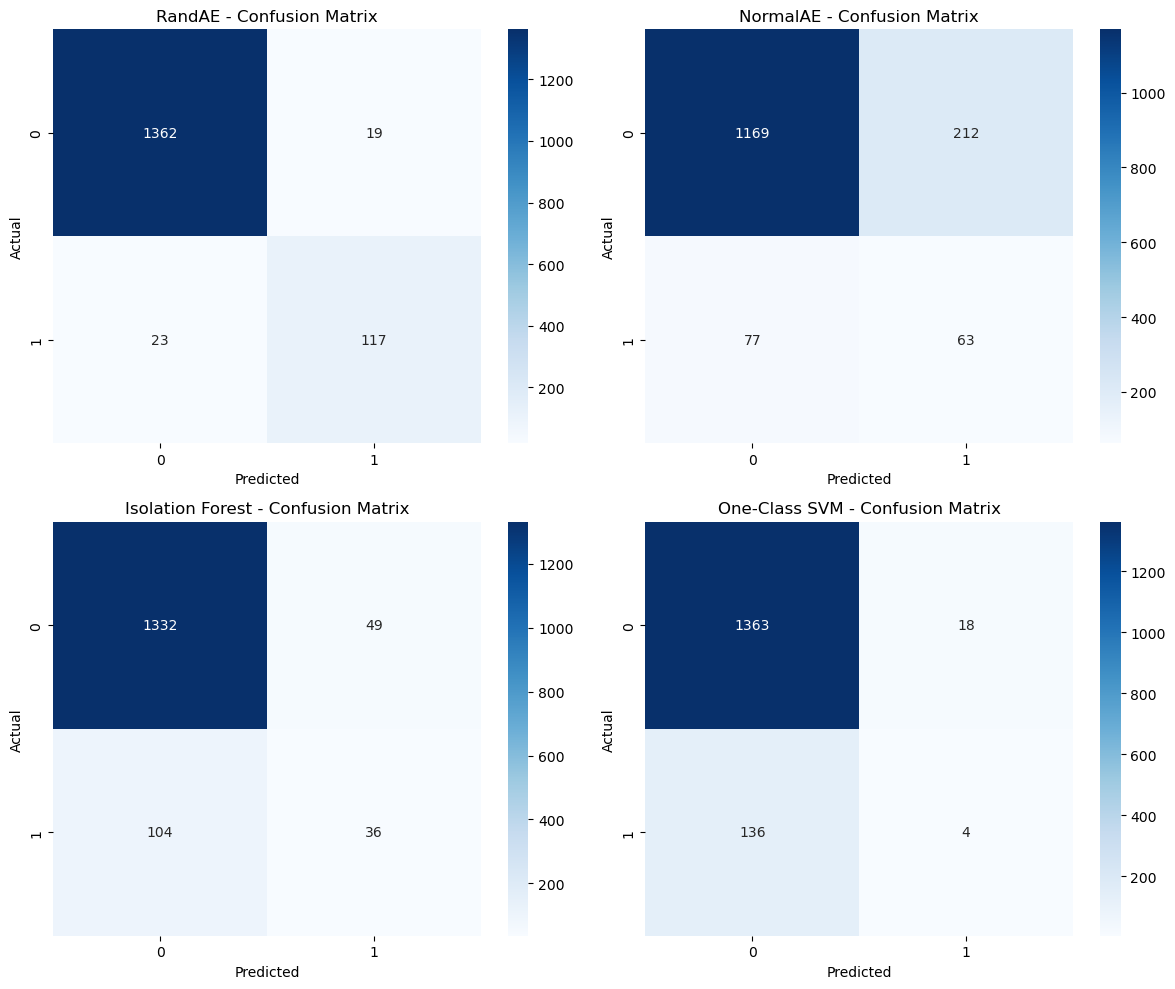

In [24]:
# Plot Confusion Matrices
plt.figure(figsize=(12, 10))
for i, res in enumerate(results):
    plt.subplot(2, 2, i + 1)
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{res['name']} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

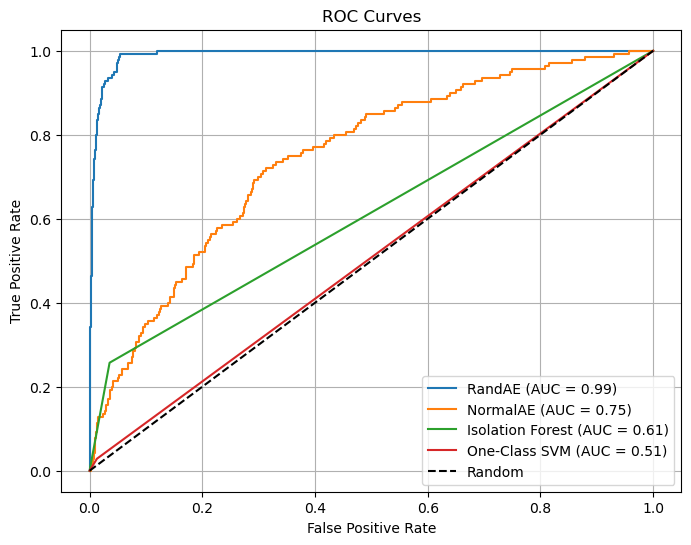

In [25]:
# Plot ROC Curves
plt.figure(figsize=(8, 6))
for res in results:
    fpr, tpr, _ = roc_curve(res["y_true"], res["scores"])
    roc_auc = roc_auc_score(res["y_true"], res["scores"])
    plt.plot(fpr, tpr, label=f"{res['name']} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

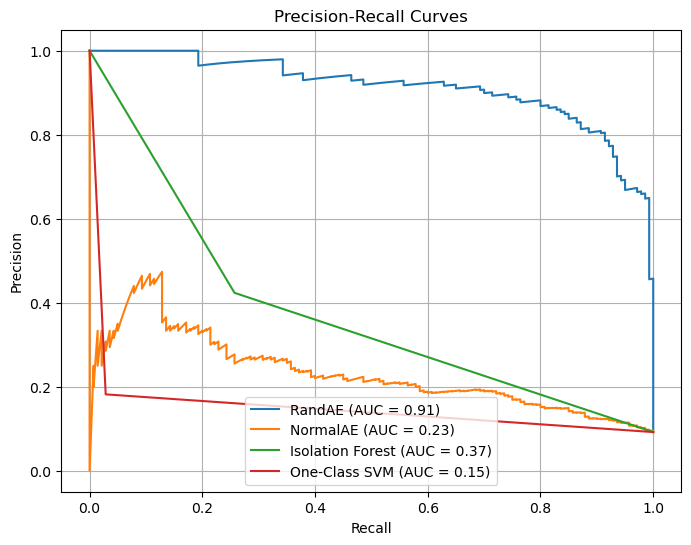

In [26]:
# Plot Precision-Recall Curves
plt.figure(figsize=(8, 6))
for res in results:
    precision, recall, _ = precision_recall_curve(res["y_true"], res["scores"])
    prc_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{res['name']} (AUC = {prc_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


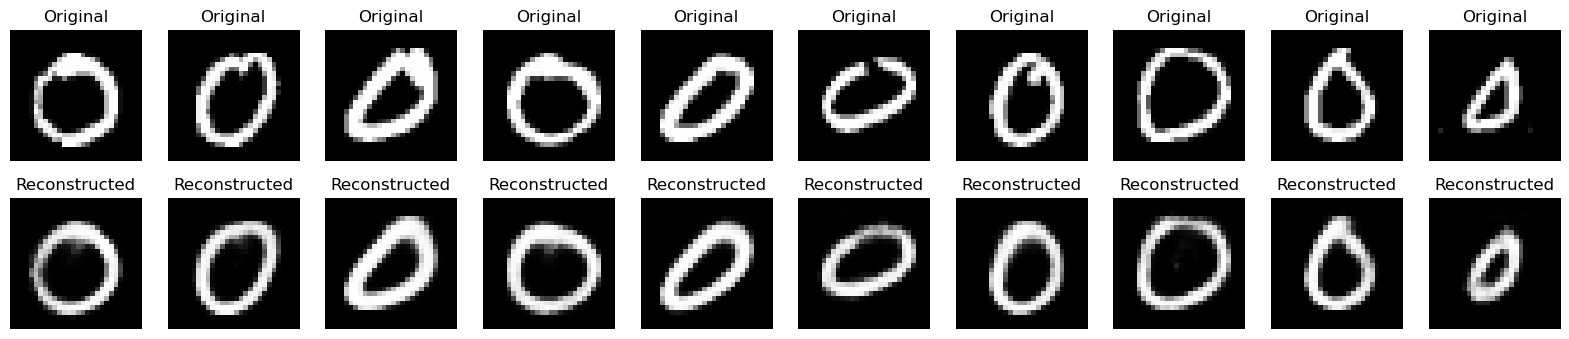

In [27]:
reconstructed = Rand_Ae.predict(X_test[:10])
plt.figure(figsize=(20, 4))
for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')
plt.show()